# `pbt_xgb` — Population Based Training for XGBoost

This notebook demonstrates the `pbt_xgb` library, which tunes XGBoost
hyperparameters with **Population Based Training (PBT)** / an evolutionary
strategy.

A population of models is trained **incrementally** (each generation appends more
boosting rounds to a warm-started booster). After each generation the strategy:

* **selects** the `top_k` fittest members (truncation selection),
* **crosses over** genes from two parents (dominant/recessive inheritance),
* **mutates** a fraction of each child's hyperparameters,

and stops on the first terminal condition (`generations`, `target_score`,
`patience`, or `max_time`).

We show both **classification** and **regression**, inspect the optimization
history, plot convergence, and save/reload results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, r2_score

from pbt_xgb import PBTXGBClassifier, PBTXGBRegressor

%matplotlib inline
RANDOM_STATE = 0
print('xgboost', xgb.__version__)

xgboost 3.3.0


## 1. The dataset

We use the project's canonical synthetic dataset: a binary problem of 1250
samples / 20 features, split into **1000 training** and **250 validation** rows.
PBT trains on the training set and measures fitness on the held-out validation
set (no leakage).

In [2]:
X, y = make_classification(
    n_samples=1250, n_features=20, n_informative=10, n_redundant=5,
    n_classes=2, random_state=42,
)
X_train, X_val = X[:1000], X[1000:]
y_train, y_val = y[:1000], y[1000:]
print('train', X_train.shape, ' validation', X_val.shape)

train (1000, 20)  validation (250, 20)


## 2. Tune a classifier with PBT

We configure the full set of controls: selection (`top_k`/`n_replace`),
crossover (`dominance`), mutation (`mutation_rate`), and early stopping
(`patience`). Fitness is ROC AUC on the validation set.

In [3]:
clf = PBTXGBClassifier(
    population_size=12,
    generations=20,        # upper bound; patience may stop earlier
    step_rounds=20,        # trees added per member per generation
    metric='roc_auc',
    top_k=4,               # keep the 4 fittest as parents
    n_replace=4,           # replace the 4 worst each generation
    crossover=True,
    dominance=0.8,         # 80% of genes from the fitter parent
    mutation_rate=0.4,     # perturb ~40% of a child's hyperparameters
    patience=4,            # stop after 4 generations with no improvement
    random_state=RANDOM_STATE,
    verbose=True,
)
clf.fit(X_train, y_train, X_val, y_val)

[gen  0] roc_auc: best=0.9845 mean=0.9723 global_best=0.9845


[gen  1] roc_auc: best=0.9858 mean=0.9824 global_best=0.9858


[gen  2] roc_auc: best=0.9864 mean=0.9846 global_best=0.9864


[gen  3] roc_auc: best=0.9864 mean=0.9850 global_best=0.9864


[gen  4] roc_auc: best=0.9858 mean=0.9851 global_best=0.9864


[gen  5] roc_auc: best=0.9859 mean=0.9854 global_best=0.9864


[gen  6] roc_auc: best=0.9860 mean=0.9856 global_best=0.9864
stopped after 7 generations: patience


In [4]:
print(f'best validation AUC : {clf.best_score_:.4f}')
print(f'stop reason         : {clf.stop_reason_} (after {clf.n_generations_} generations)')
print(f'best #trees          : {clf.best_num_trees_}')
print('\nbest hyperparameters:')
for k, v in clf.best_params_.items():
    print(f'  {k:18s} = {v}')

best validation AUC : 0.9864
stop reason         : patience (after 7 generations)
best #trees          : 60

best hyperparameters:
  eta                = 0.1709165062827047
  max_depth          = 7
  min_child_weight   = 3.3472629601051556
  gamma              = 2.113436105988292
  subsample          = 0.5
  colsample_bytree   = 0.5621416382497819
  reg_lambda         = 0.48139065887826193
  reg_alpha          = 0.005042228030788951


## 3. Inspect the optimization history

`clf.history_` records the best / mean / worst / running-best fitness for every
generation. The **mean** rising toward the **best** is selection at work; the
**running best** (`global_best_score`) is monotonic.

In [5]:
history = pd.DataFrame(clf.history_)
history[['generation', 'best_score', 'mean_score', 'worst_score', 'global_best_score']]

,generation,best_score,mean_score,worst_score,global_best_score
0,0,0.984527,0.972305,0.945236,0.984527
1,1,0.985812,0.982425,0.978236,0.985812
2,2,0.986389,0.984565,0.981895,0.986389
3,3,0.986389,0.985046,0.983372,0.986389
4,4,0.985812,0.985100,0.983629,0.986389
5,5,0.985876,0.985437,0.983821,0.986389
6,6,0.986004,0.985608,0.984078,0.986389


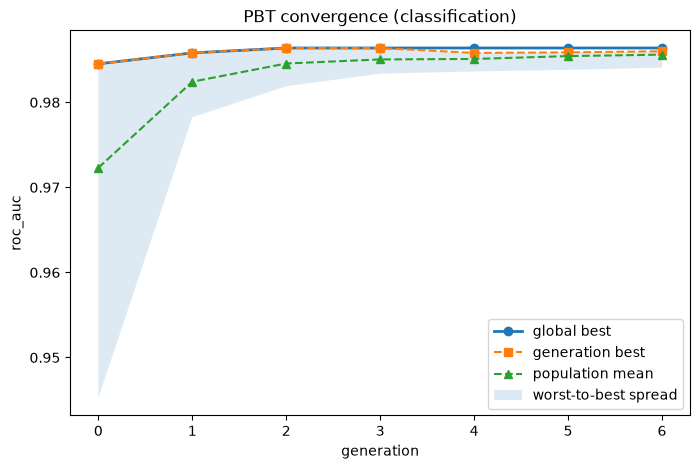

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history.generation, history.global_best_score, 'o-', label='global best', linewidth=2)
ax.plot(history.generation, history.best_score, 's--', label='generation best')
ax.plot(history.generation, history.mean_score, '^--', label='population mean')
ax.fill_between(history.generation, history.worst_score, history.best_score, alpha=0.15,
                label='worst-to-best spread')
ax.set_xlabel('generation')
ax.set_ylabel(clf._scorer.name)
ax.set_title('PBT convergence (classification)')
ax.legend()
plt.show()

## 4. Evaluate vs a default-hyperparameter baseline

We compare the tuned model against a stock XGBoost trained for the same number of
boosting rounds.

In [7]:
proba = clf.predict_proba(X_val)[:, 1]
tuned_auc = roc_auc_score(y_val, proba)
tuned_acc = accuracy_score(y_val, clf.predict(X_val))

dtrain = xgb.DMatrix(X_train, label=y_train)
base = xgb.train({'objective': 'binary:logistic', 'tree_method': 'hist', 'verbosity': 0},
                 dtrain, num_boost_round=clf.best_num_trees_)
base_auc = roc_auc_score(y_val, base.predict(xgb.DMatrix(X_val)))

print(f'tuned  (PBT)     AUC = {tuned_auc:.4f}   accuracy = {tuned_acc:.4f}')
print(f'default baseline AUC = {base_auc:.4f}   ({clf.best_num_trees_} trees)')

tuned  (PBT)     AUC = 0.9864   accuracy = 0.9640
default baseline AUC = 0.9829   (60 trees)


## 5. Regression

`PBTXGBRegressor` shares the exact same evolutionary engine and controls; only
the objective/metric differ. The default metric is R² (maximize), and there is no
`predict_proba`.

In [8]:
Xr, yr = make_regression(n_samples=2000, n_features=20, n_informative=12,
                         noise=15.0, random_state=42)
Xr_tr, Xr_va, yr_tr, yr_va = train_test_split(Xr, yr, test_size=0.25, random_state=0)

reg = PBTXGBRegressor(
    population_size=12, generations=15, step_rounds=20,
    metric='r2', patience=5, random_state=RANDOM_STATE, verbose=False,
)
reg.fit(Xr_tr, yr_tr, Xr_va, yr_va)

print(f'best validation R2 : {reg.best_score_:.4f}')
print(f'final  validation R2: {r2_score(yr_va, reg.predict(Xr_va)):.4f}')
print(f'stop reason        : {reg.stop_reason_} (after {reg.n_generations_} generations)')
print(f'best params        : {reg.best_params_}')

best validation R2 : 0.9219
final  validation R2: 0.9219
stop reason        : max_generations (after 15 generations)
best params        : {'eta': 0.13312777419299296, 'max_depth': 5, 'min_child_weight': 4.245861520795637, 'gamma': 1.6907488847906338, 'subsample': 0.5, 'colsample_bytree': 1.0, 'reg_lambda': 0.9665075192171555, 'reg_alpha': 5.134639760671632}


## 6. Save and reload results

`save_results(dir)` writes `summary.json`, `history.csv`, and `best_model.json`
so a run can be reviewed (or the model reused) later without re-training.

In [9]:
out = clf.save_results('results_notebook')
print('saved to', out)

# reload the booster and confirm identical predictions
reloaded = xgb.Booster(model_file=str(out / 'best_model.json'))
same = np.allclose(reloaded.predict(xgb.DMatrix(X_val)), clf.predict_proba(X_val)[:, 1], rtol=1e-6)
print('reloaded model reproduces predictions:', same)

saved to results_notebook
reloaded model reproduces predictions: True


## Summary

* `PBTXGBClassifier` / `PBTXGBRegressor` tune XGBoost via warm-start incremental
  PBT with configurable selection, crossover, mutation, and stopping criteria.
* Fitness is always measured on the held-out validation set.
* `history_` exposes the full optimization trace; `save_results` persists it.

See `pbt_xgb/README.md` for the full API and `examples/` for runnable scripts.